# Diabetes Prediction using Machine Learning

Import Dependencies:


In [50]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

# Loading the Dataset

The Diabetes dataset is loaded into a Pandas DataFrame for inspection and analysis.

In [51]:
diabetes_df = pd.read_csv("diabetes.csv")

diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Dataset Inspection

The dataset is inspected to understand its structure, dimensions, data types, missing values, and overall quality before model training.

In [52]:
print("Dataset Shape:")
print(diabetes_df.shape)

print("Column Names:")
print(diabetes_df.columns)

diabetes_df.info()

diabetes_df.isnull().sum()


Dataset Shape:
(768, 9)
Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [53]:
print("Duplicate Rows:", diabetes_df.duplicated().sum())

Duplicate Rows: 0


In [54]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Data Cleaning

The dataset contained medically impossible zero values in certain features.
These values were treated as missing values and replaced using the median of the respective feature.

In [55]:
# ==========================================
# REPLACE INVALID ZEROS WITH NaN
# ==========================================

columns_to_fix = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns_to_fix:
    diabetes_df[col] = diabetes_df[col].replace(0, np.nan)

diabetes_df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [56]:
# ==========================================
# FILL MISSING VALUES USING MEDIAN
# ==========================================

for col in columns_to_fix:
    diabetes_df[col] = diabetes_df[col].fillna(
        diabetes_df[col].median()
    )

diabetes_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [57]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Exploratory Data Analysis (EDA)

EDA is performed to understand the distribution of diabetes cases and identify relationships between features.

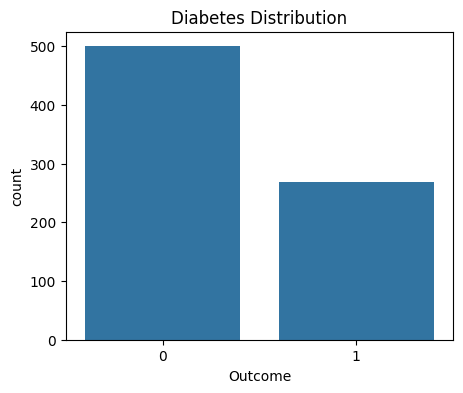

In [58]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="Outcome",
    data=diabetes_df
)

plt.title("Diabetes Distribution")

plt.show()

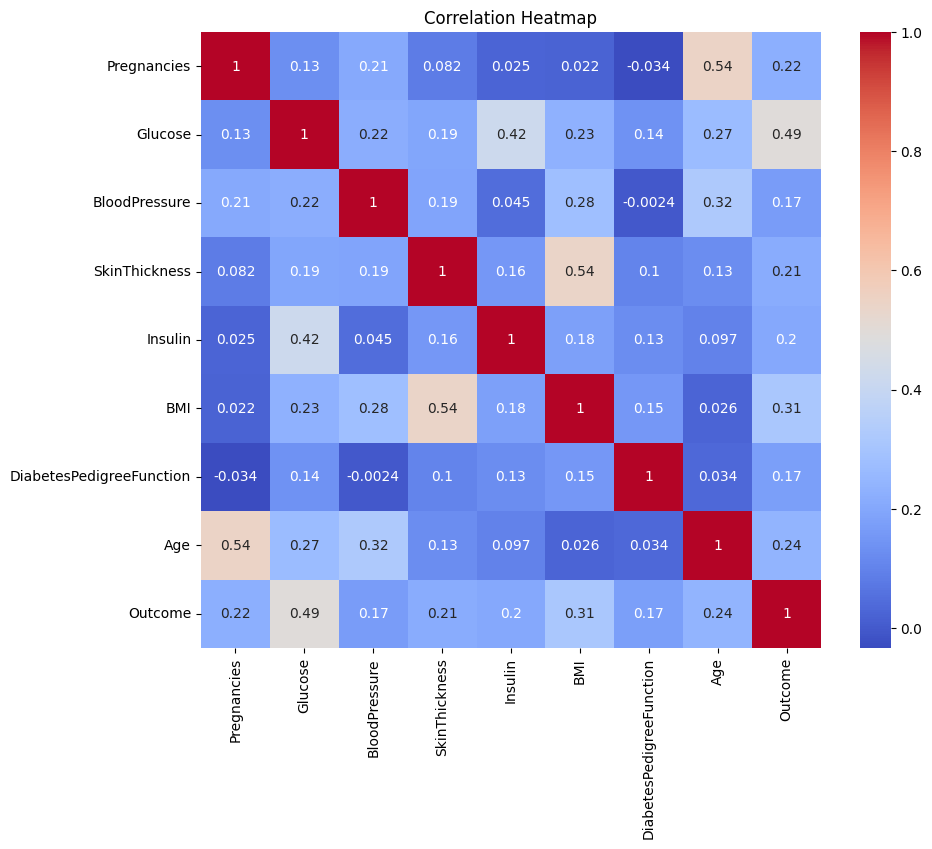

In [59]:
plt.figure(figsize=(10,8))

sns.heatmap(
    diabetes_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [60]:
X = diabetes_df.drop("Outcome", axis=1)

y = diabetes_df["Outcome"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (768, 8)
y Shape : (768,)


In [61]:
diabetes_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# Train-Test-Split

In [62]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (614, 8)
Testing Shape  : (154, 8)


# Feature Scaling

Feature scaling is applied to standardize the data and improve model performance.

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


# Logistic Regression Model

Logistic Regression is trained on the standardized dataset and evaluated on the test set.

In [64]:

lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=5000)

In [65]:
lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.7077922077922078


# Random Forest Model

Random Forest is trained and evaluated on the same test dataset.

In [66]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [67]:
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.7792207792207793


# Model Comparison

The performance of Logistic Regression and Random Forest is compared using accuracy scores.

In [68]:

print("Logistic Regression :", lr_accuracy)
print("Random Forest       :", rf_accuracy)

Logistic Regression : 0.7077922077922078
Random Forest       : 0.7792207792207793


# Confusion Matrix

Confusion matrices are plotted to visualize correct and incorrect predictions made by each model.

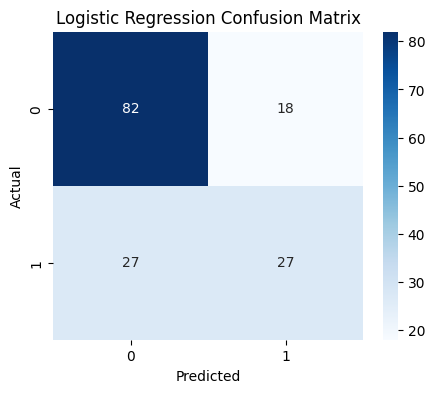

In [69]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

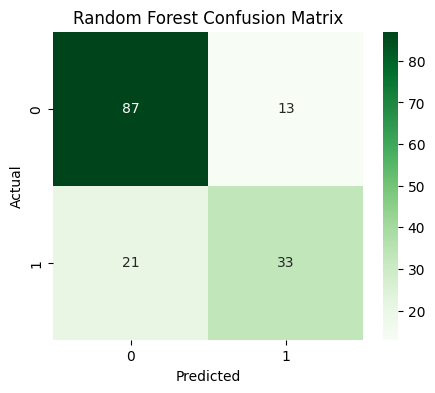

In [70]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report

Precision, Recall, and F1-Score are calculated to evaluate model performance in greater detail.

In [71]:
print("========== Logistic Regression ==========\n")
print(classification_report(y_test, lr_pred))

print("\n========== Random Forest ==========\n")
print(classification_report(y_test, rf_pred))

========== Logistic Regression ==========

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


========== Random Forest ==========

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



# Model Selection

Both Logistic Regression and Random Forest were evaluated.

Random Forest achieved higher accuracy, precision, recall, and F1-score compared to Logistic Regression.

Therefore, Random Forest was selected as the final model for Diabetes Prediction.

# Manual Prediction Test

In [72]:
# Sample Patient Data
input_data = [[6,148,72,35,125,33.6,0.627,50]]

prediction = rf_model.predict(
    scaler.transform(input_data)
)

if prediction[0] == 0:
    print("✅ Person is NOT Diabetic")
else:
    print("⚠️ Person is Diabetic")

⚠️ Person is Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Save the Final Model

In [73]:
import joblib

joblib.dump(rf_model, "diabetes_model.pkl")

print("Diabetes Model Saved Successfully")

Diabetes Model Saved Successfully


In [74]:
# ==========================================
# DOWNLOAD MODEL
# ==========================================

from google.colab import files

files.download("diabetes_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>